In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics  import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers, models, Sequential, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.utils import image_dataset_from_directory, load_img, img_to_array
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2
from sklearn.metrics import  f1_score, recall_score, accuracy_score
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import StratifiedKFold
from collections import Counter
# librerias para preprocesamiento y metricas
from pprint import pformat
from sklearn.preprocessing import label_binarize
from sklearn.metrics  import classification_report, confusion_matrix, roc_curve, auc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
import warnings
import time
import GPUtil
import os

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

In [3]:
def load_dataset_info(data_dir):
    """
    Recorre el directorio 'data_dir' con la siguiente estructura:
      data_dir/
          clase1/
              imágenes...
          clase2/
              imágenes...
    Retorna:
      - file_paths: array con las rutas completas de las imágenes.
      - labels: array con las etiquetas numéricas.
      - classes: lista de nombres de las clases (ordenadas alfabéticamente).
    """
    file_paths = []
    labels = []
    classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    class_indices = {c: i for i, c in enumerate(classes)}
    
    for c in classes:
        class_folder = os.path.join(data_dir, c)
        for fname in os.listdir(class_folder):
            if fname.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp')):
                full_path = os.path.join(class_folder, fname)
                if os.path.isfile(full_path):
                    file_paths.append(full_path)
                    labels.append(class_indices[c])
                else:
                    print(f"Advertencia: '{full_path}' no es un archivo válido.")
    return np.array(file_paths), np.array(labels), classes

In [4]:
# Sección 2: Preprocesamiento de Imágenes
def preprocess_image(file_path, label, target_size=(224, 224)):
    """
    Lee la imagen desde disco, la decodifica, redimensiona y normaliza.
    """
    image = tf.io.read_file(file_path)
    image = tf.image.decode_image(image, channels=3)  # Forzar 3 canales
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, target_size)
    image = tf.cast(image, tf.float32) / 255.0  # Normalización a [0, 1]
    return image, label

In [5]:
# Sección 3: Creación del Dataset tf.data
def create_dataset(file_paths, labels, batch_size, target_size=(224, 224)):
    """
    Crea un objeto tf.data.Dataset a partir de arrays de rutas y etiquetas.
    """
    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    ds = ds.map(lambda x, y: preprocess_image(x, y, target_size), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(buffer_size=len(file_paths))
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [6]:
# Sección 4: Creación del Modelo
def create_model(num_classes, input_shape=(224, 224, 3)):
    base_model = VGG16(weights="imagenet", include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Congelar la base para transfer learning
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

In [7]:
# Sección 5: Entrenamiento con transfer learning
def train_transfer_learning(model, train_ds, val_ds, epochs, callbacks=None):
    """
    Entrena el modelo en modo transfer learning (base congelada).
    """
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Tasa de aprendizaje para las capas superiores
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    if callbacks is None:
        callbacks = [early_stopping]
    else:
        callbacks.append(early_stopping)
    
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks)
    return history

#Entrenamiento con fine-tuning

def fine_tune_model(model, train_ds, val_ds, fine_tune_at, epochs, callbacks=None):
        """
        Realiza fine-tuning:
          - Descongela la base a partir del índice 'fine_tune_at'.
          - Compila con una tasa de aprendizaje baja.
          - Entrena para ajustar la base y las capas superiores.
        """
        base_model = model.layers[0]
        base_model.trainable = True
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False
    
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(),
            metrics=["accuracy"]
        )
        early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
        if callbacks is None:
            callbacks = [early_stopping]
        else:
            callbacks.append(early_stopping)
        
        history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks)
        return history

In [8]:
# 6. Función para Calcular la Matriz de Confusión
def compute_confusion_matrix(model, dataset, classes):
    """
    Calcula la matriz de confusión para el conjunto 'dataset' usando el modelo dado.
    """
    y_true = []
    y_pred = []
    for images, labels in dataset:
        preds = model.predict(images)
        preds = tf.argmax(preds, axis=1).numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())
    cm = confusion_matrix(y_true, y_pred)
    return cm

def plot_aggregated_confusion_matrix(cm, classes, title="Matriz de Confusión"):
    """
    Grafica la matriz de confusión 'cm' usando Seaborn.
    """
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.xlabel("Etiqueta Predicha")
    plt.ylabel("Etiqueta Verdadera")
    plt.title(title)
    plt.show()

In [9]:
def run_cross_validation( file_paths, labels, classes, k, 
                         transfer_epochs, fine_tune_epochs,  
                         batch_size, target_size,  
                         fine_tune_at ):
    """
    Ejecuta k-fold cross validation para una representación dada.
    Para cada fold, se entrena el modelo en dos fases:
      1) Transfer learning durante 'transfer_epochs'.
      2) Fine-tuning (descongelando la base a partir de 'fine_tune_at')
         durante 'fine_tune_epochs'.
    Además, se calcula la matriz de confusión para el conjunto de validación en cada fase.
    Retorna un diccionario con, para cada fold:
          {"transfer": transfer_history, "transfer_cm": transfer_cm,
           "fine": fine_history, "fine_cm": fine_cm}
    """
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    fold_no = 1
    histories = {}
    transfer_cms = []
    fine_cms = []
    
    for train_index, val_index in skf.split(file_paths, labels):
        print(f"\nFold {fold_no}")
        train_files, val_files = file_paths[train_index], file_paths[val_index]
        train_labels, val_labels = labels[train_index], labels[val_index]
        
        train_ds = create_dataset(train_files, train_labels, batch_size, target_size)
        val_ds = create_dataset(val_files, val_labels, batch_size, target_size)
        
        model = create_model(num_classes=len(classes), input_shape=(target_size[0], target_size[1], 3))
        
        # Fase 1: Transfer Learning
        transfer_history = train_transfer_learning(model, train_ds, val_ds, epochs=transfer_epochs)
        transfer_cm = compute_confusion_matrix(model, val_ds, classes)
        
        # Fase 2: Fine-Tuning (continúa sobre el modelo entrenado)
        fine_history = fine_tune_model(model, train_ds, val_ds, fine_tune_at=fine_tune_at, epochs=fine_tune_epochs)
        fine_cm = compute_confusion_matrix(model, val_ds, classes)
        
        histories[f"fold_{fold_no}"] = {
            "transfer": transfer_history,
            "transfer_cm": transfer_cm,
            "fine": fine_history,
            "fine_cm": fine_cm
        }
        transfer_cms.append(transfer_cm)
        fine_cms.append(fine_cm)
        fold_no += 1
        
    # Agregar matrices acumuladas (suma de las matrices de cada fold)
    agg_transfer_cm = np.sum(transfer_cms, axis=0)
    agg_fine_cm = np.sum(fine_cms, axis=0)
    
    return histories, agg_transfer_cm, agg_fine_cm



Procesando la representación: Mel-2048
  -> Se cargaron 5362 imágenes en 7 clases para Mel-2048.

Fold 1
Epoch 1/50
224/224 [==============================] - 43s 114ms/step - loss: 2.2877 - accuracy: 0.1718 - val_loss: 1.9104 - val_accuracy: 0.2338
Epoch 2/50
224/224 [==============================] - 25s 99ms/step - loss: 2.0404 - accuracy: 0.2289 - val_loss: 1.7615 - val_accuracy: 0.3115
Epoch 3/50
224/224 [==============================] - 28s 111ms/step - loss: 1.8912 - accuracy: 0.2792 - val_loss: 1.5967 - val_accuracy: 0.3887
Epoch 4/50
224/224 [==============================] - 30s 119ms/step - loss: 1.7547 - accuracy: 0.3335 - val_loss: 1.4892 - val_accuracy: 0.4530
Epoch 5/50
224/224 [==============================] - 31s 119ms/step - loss: 1.6679 - accuracy: 0.3629 - val_loss: 1.4089 - val_accuracy: 0.4961
Epoch 6/50
224/224 [==============================] - 35s 137ms/step - loss: 1.6077 - accuracy: 0.4068 - val_loss: 1.3540 - val_accuracy: 0.5224
Epoch 7/50
224/224 [=====

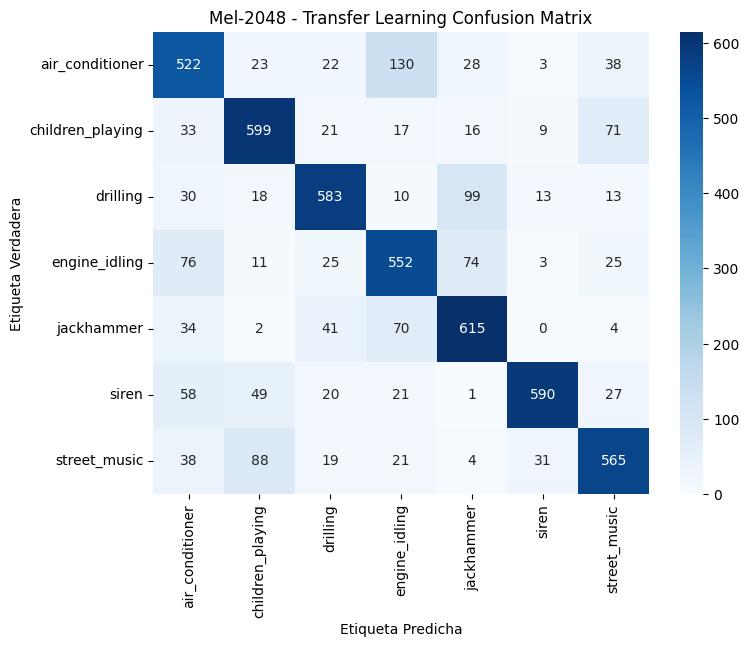

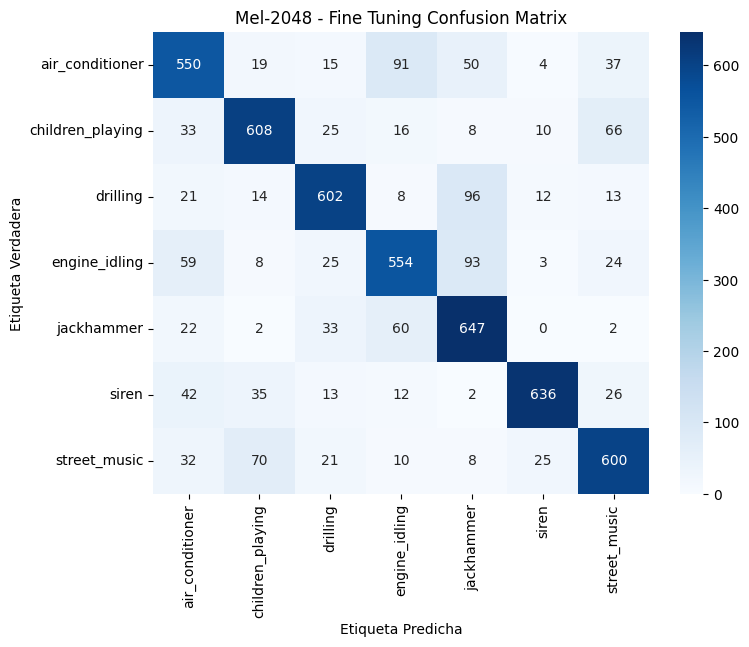


Representación: Mel-2048
  Folds evaluados: ['fold_1', 'fold_2', 'fold_3']


In [10]:
# 8. Pipeline Principal: Cross Validation para 5 Representaciones
data_paths = {
    "Mel-2048": "..\\..\\Analisis_Espectros\\DataSetImages_FULL\DataSetImages\\Spectrograms\\Mel-2048",
}
# Parámetros generales para cross validation
k = 3
transfer_epochs = 50
fine_tune_epochs = 1
batch_size = 16
target_size = (224, 224)
fine_tune_at = 4

all_results = {}  # Aquí se almacenarán historiales y matrices de confusión para cada representación

for rep_name, rep_path in data_paths.items():
    print(f"\nProcesando la representación: {rep_name}")
    if not os.path.exists(rep_path) or not os.path.isdir(rep_path):
        print(f"Error: La ruta '{rep_path}' no es válida.")
        continue
    
    file_paths, labels, classes = load_dataset_info(rep_path)
    print(f"  -> Se cargaron {len(file_paths)} imágenes en {len(classes)} clases para {rep_name}.")
    
    histories, agg_transfer_cm, agg_fine_cm = run_cross_validation(
        file_paths, labels, classes,
        k=k,
        transfer_epochs=transfer_epochs,
        fine_tune_epochs=fine_tune_epochs,
        batch_size=batch_size,
        target_size=target_size,
        fine_tune_at=fine_tune_at
    )
    
    all_results[rep_name] = {
        "histories": histories,
        "agg_transfer_cm": agg_transfer_cm,
        "agg_fine_cm": agg_fine_cm,
        "classes": classes
    }
    
    # Graficar la matriz de confusión acumulada para Transfer Learning
    plot_aggregated_confusion_matrix(agg_transfer_cm, classes, title=f"{rep_name} - Transfer Learning Confusion Matrix")
    # Graficar la matriz de confusión acumulada para Fine Tuning
    plot_aggregated_confusion_matrix(agg_fine_cm, classes, title=f"{rep_name} - Fine Tuning Confusion Matrix")
    
# Imprimir resumen de resultados para cada representación
for rep_name, result in all_results.items():
    print(f"\nRepresentación: {rep_name}")
    print(f"  Folds evaluados: {list(result['histories'].keys())}")

In [11]:

# Función para calcular métricas desde matriz de confusión acumulada
def compute_metrics_from_confusion(cm):
    TP = np.diag(cm)
    FN = np.sum(cm, axis=1) - TP
    FP = np.sum(cm, axis=0) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    with np.errstate(divide='ignore', invalid='ignore'):
        specificity = TN / (TN + FP)
        specificity[np.isnan(specificity)] = 0

    accuracy = np.sum(TP) / np.sum(cm)
    macro_recall = np.mean(TP / (TP + FN))
    macro_f1 = 2 * (macro_recall * accuracy) / (macro_recall + accuracy) if (macro_recall + accuracy) != 0 else 0
    macro_specificity = np.mean(specificity)
    
    return accuracy, macro_recall, macro_f1, macro_specificity

In [12]:
# Calcular métricas y mostrar resultado por cada representación
metrics_summary = []

for rep_name, result in all_results.items():
    print(f"\n Evaluación Final - Representación: {rep_name}")

    for stage, cm_key in zip(["Transfer Learning", "Fine-Tuning"], ["agg_transfer_cm", "agg_fine_cm"]):
        cm = result[cm_key]
        acc, recall, f1, spec = compute_metrics_from_confusion(cm)

        print(f"\n Etapa: {stage}")
        print(f"  - Accuracy         : {acc:.4f}")
        print(f"  - Macro Recall     : {recall:.4f}")
        print(f"  - Macro F1         : {f1:.4f}")
        print(f"  - Macro Specificity: {spec:.4f}")

        metrics_summary.append({
            "Representation": rep_name,
            "Stage": stage,
            "Accuracy": acc,
            "Macro Recall": recall,
            "Macro F1": f1,
            "Macro Specificity": spec
        })

# Mostrar tabla final al usuario
results_df = pd.DataFrame(metrics_summary)


🔍 Evaluación Final - Representación: Mel-2048

📌 Etapa: Transfer Learning
  - Accuracy         : 0.7508
  - Macro Recall     : 0.7508
  - Macro F1         : 0.7508
  - Macro Specificity: 0.9585

📌 Etapa: Fine-Tuning
  - Accuracy         : 0.7827
  - Macro Recall     : 0.7827
  - Macro F1         : 0.7827
  - Macro Specificity: 0.9638


In [13]:
all_results

{'Mel-2048': {'histories': {'fold_1': {'transfer': <keras.callbacks.History at 0x2a32a81db80>,
    'transfer_cm': array([[182,   4,   7,  36,  13,   1,  13],
           [ 16, 189,  10,   3,   5,   2,  30],
           [  9,   4, 207,   4,  26,   2,   3],
           [ 37,   0,   4, 176,  28,   1,  10],
           [ 13,   2,   8,  18, 212,   0,   2],
           [ 25,  13,   8,   7,   1, 194,   7],
           [  7,  30,   5,   6,   2,  15, 191]], dtype=int64),
    'fine': <keras.callbacks.History at 0x2a33c8008e0>,
    'fine_cm': array([[182,   8,   4,  19,  28,   3,  12],
           [  9, 208,   9,   3,   2,   1,  23],
           [  4,   4, 206,   2,  32,   3,   4],
           [ 25,   1,   3, 173,  41,   2,  11],
           [  3,   2,   7,   7, 235,   0,   1],
           [ 15,  13,   6,   2,   1, 214,   4],
           [  5,  35,   3,   3,   3,  13, 194]], dtype=int64)},
   'fold_2': {'transfer': <keras.callbacks.History at 0x2a42cc42640>,
    'transfer_cm': array([[167,  12,   3,  50,   7